In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.datasets import make_blobs, make_moons
from sklearn.metrics import silhouette_score, adjusted_rand_score

# Set style for better plots
sns.set(style="whitegrid", context="talk")
np.random.seed(42)

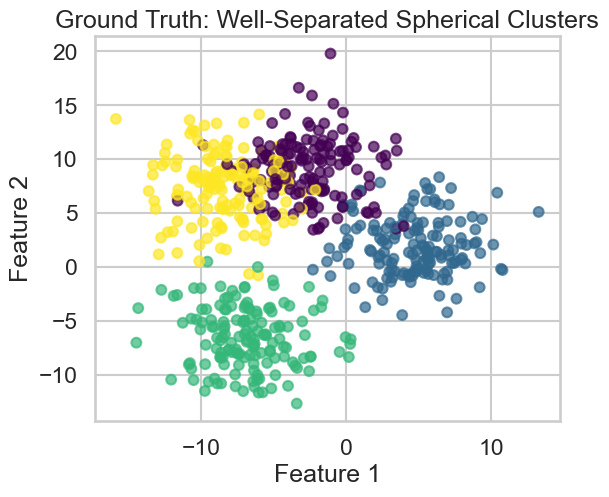

In [2]:
# 1. Generate Spherical Data
X_blobs, y_true = make_blobs(n_samples=600, centers=4, cluster_std=2.8, random_state=42)

# 2. Visualize Ground Truth
plt.figure(figsize=(6, 5))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=y_true, cmap="viridis", s=50, alpha=0.7)
plt.title("Ground Truth: Well-Separated Spherical Clusters")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

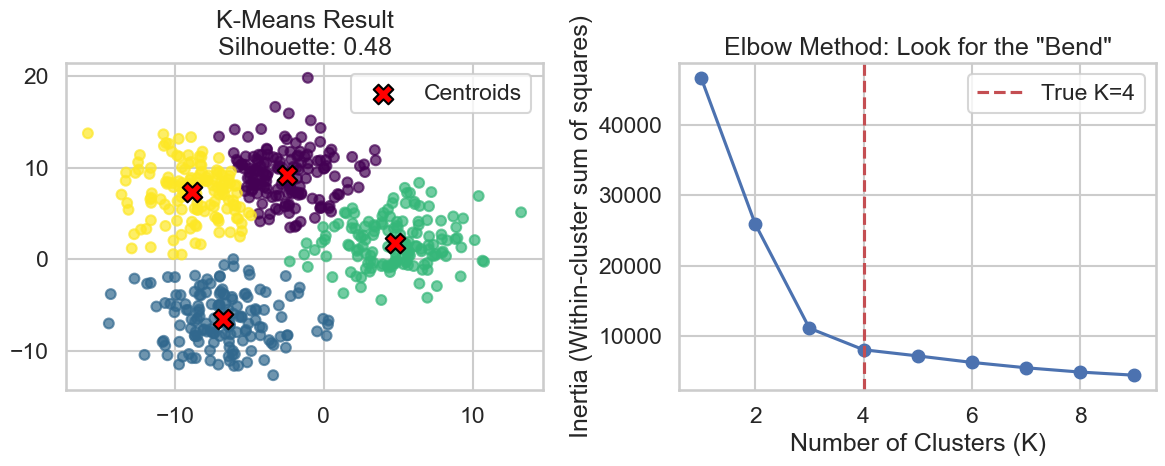

In [3]:
# 3. Apply K-Means
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X_blobs)

# 4. Visualize Result
plt.figure(figsize=(12, 5))

# Plot Clusters
plt.subplot(1, 2, 1)
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=y_kmeans, cmap="viridis", s=50, alpha=0.7)
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    c="red",
    s=200,
    marker="X",
    edgecolors="black",
    label="Centroids",
)
plt.title(f"K-Means Result\nSilhouette: {silhouette_score(X_blobs, y_kmeans):.2f}")
plt.legend()

# Plot Elbow Method (Finding optimal K)
inertias = []
K_range = range(1, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_blobs)
    inertias.append(km.inertia_)

plt.subplot(1, 2, 2)
plt.plot(K_range, inertias, "bo-")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (Within-cluster sum of squares)")
plt.title('Elbow Method: Look for the "Bend"')
plt.axvline(x=4, color="r", linestyle="--", label="True K=4")
plt.legend()

plt.tight_layout()
plt.show()

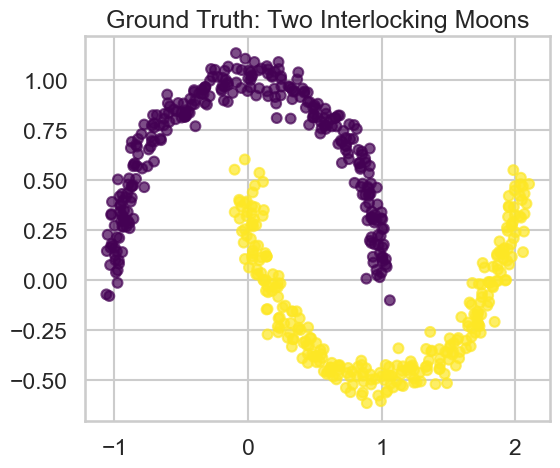

In [4]:
# 1. Generate Moon Data
X_moons, y_true_moons = make_moons(n_samples=600, noise=0.05, random_state=42)

# 2. Visualize Ground Truth
plt.figure(figsize=(6, 5))
plt.scatter(
    X_moons[:, 0], X_moons[:, 1], c=y_true_moons, cmap="viridis", s=50, alpha=0.7
)
plt.title("Ground Truth: Two Interlocking Moons")
plt.show()

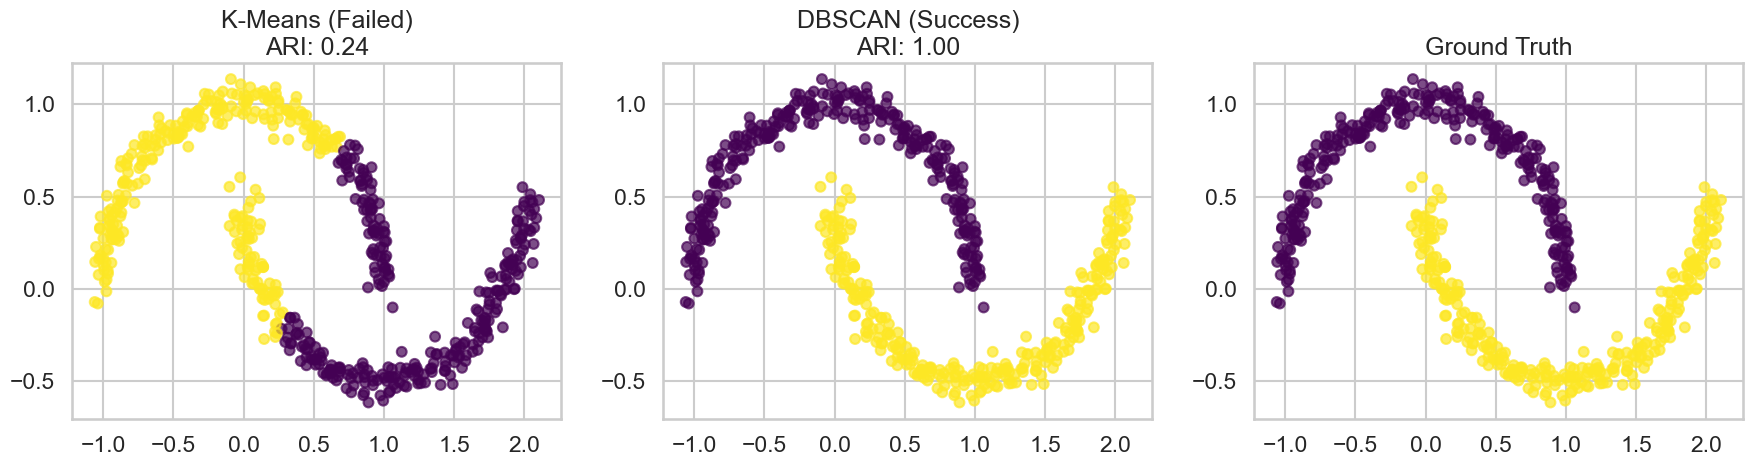

In [5]:
# 3. Apply K-Means (The Wrong Tool)
kmeans_moons = KMeans(n_clusters=2, random_state=42, n_init=10)
y_kmeans_moons = kmeans_moons.fit_predict(X_moons)

# 4. Apply DBSCAN (The Right Tool)
# eps: radius to look for neighbors, min_samples: min people to form a crowd
dbscan = DBSCAN(eps=0.2, min_samples=5)
y_dbscan = dbscan.fit_predict(X_moons)

# 5. Compare Results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# K-Means Failure
axes[0].scatter(
    X_moons[:, 0], X_moons[:, 1], c=y_kmeans_moons, cmap="viridis", s=50, alpha=0.7
)
axes[0].set_title(
    f"K-Means (Failed)\nARI: {adjusted_rand_score(y_true_moons, y_kmeans_moons):.2f}"
)

# DBSCAN Success
# Note: DBSCAN labels noise as -1. We handle coloring slightly differently if needed,
# but standard cmap works fine usually, just ignoring -1 or mapping it.
axes[1].scatter(
    X_moons[:, 0], X_moons[:, 1], c=y_dbscan, cmap="viridis", s=50, alpha=0.7
)
axes[1].set_title(
    f"DBSCAN (Success)\nARI: {adjusted_rand_score(y_true_moons, y_dbscan):.2f}"
)

# Ground Truth for reference
axes[2].scatter(
    X_moons[:, 0], X_moons[:, 1], c=y_true_moons, cmap="viridis", s=50, alpha=0.7
)
axes[2].set_title("Ground Truth")

plt.tight_layout()
plt.show()

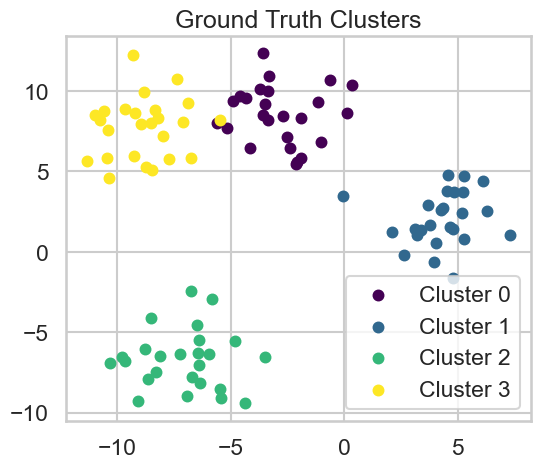

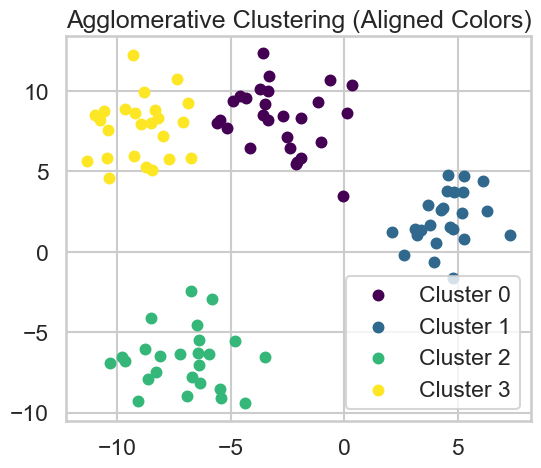

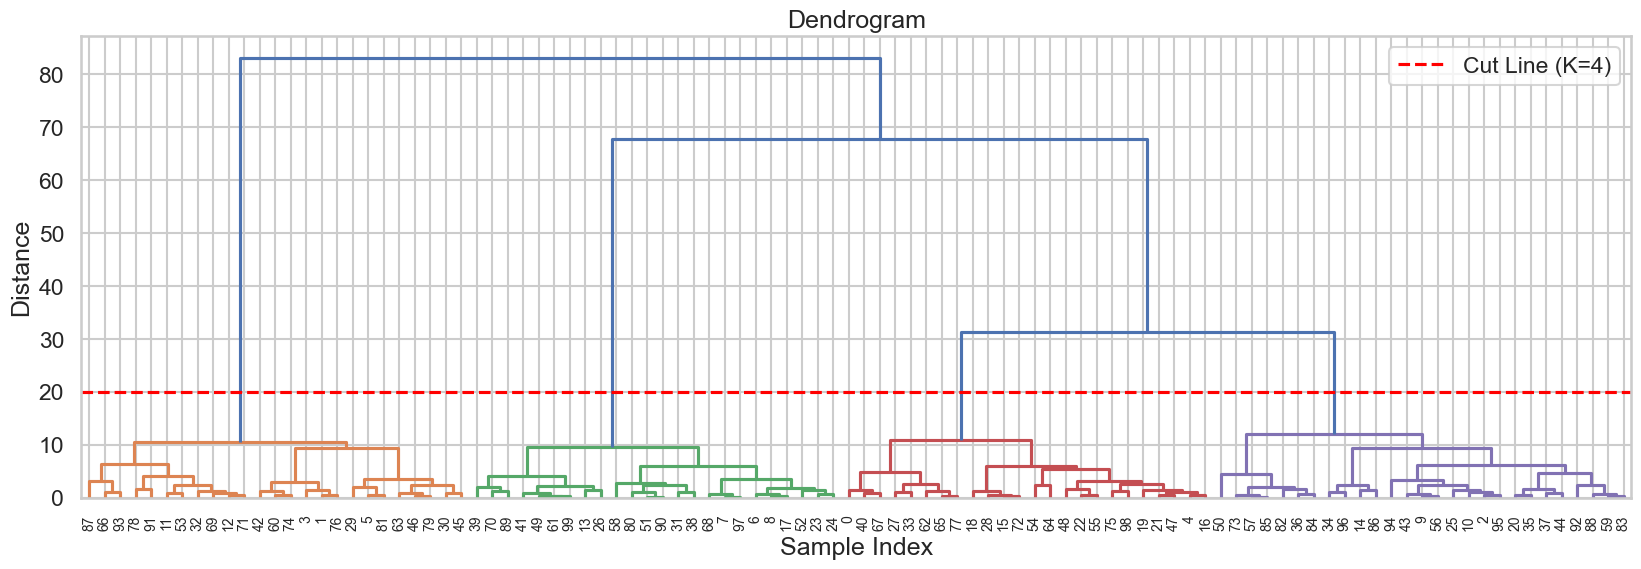

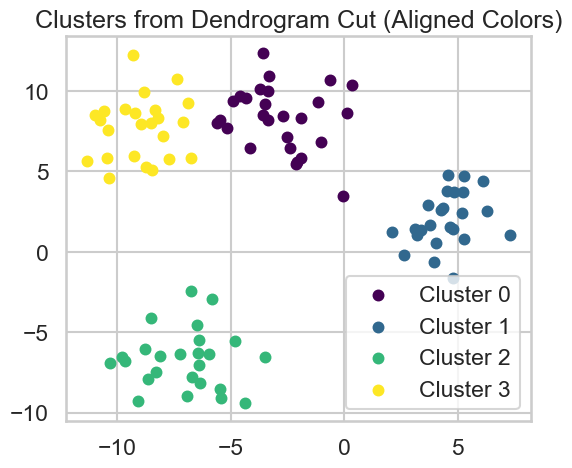

In [6]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import confusion_matrix

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.optimize import linear_sum_assignment


# -----------------------------
# helper: align cluster labels
# -----------------------------
def align_labels(true_labels, pred_labels):
    cm = confusion_matrix(true_labels, pred_labels)

    row_ind, col_ind = linear_sum_assignment(-cm)

    mapping = {col: row for row, col in zip(row_ind, col_ind)}

    aligned = np.vectorize(mapping.get)(pred_labels)

    return aligned


# -----------------------------
# helper: plotting function
# -----------------------------
def plot_clusters(X, labels, title, colors):
    plt.figure(figsize=(6, 5))

    for i in range(len(colors)):
        idx = labels == i
        plt.scatter(X[idx, 0], X[idx, 1], color=colors[i], s=50, label=f"Cluster {i}")

    plt.title(title)
    plt.legend()
    plt.show()


# -----------------------------
# 1 Generate Data
# -----------------------------
X, y_true = make_blobs(n_samples=100, centers=4, cluster_std=1.8, random_state=42)

colors = ["#440154", "#31688e", "#35b779", "#fde725"]

plot_clusters(X, y_true, "Ground Truth Clusters", colors)


# -----------------------------
# 2 Agglomerative Clustering
# -----------------------------
model = AgglomerativeClustering(n_clusters=4, linkage="ward")

y_pred = model.fit_predict(X)

# align labels with ground truth
y_pred_aligned = align_labels(y_true, y_pred)

plot_clusters(X, y_pred_aligned, "Agglomerative Clustering (Aligned Colors)", colors)


# -----------------------------
# 3 Dendrogram
# -----------------------------
Z = linkage(X, method="ward")

plt.figure(figsize=(20, 6))

dendrogram(Z, leaf_rotation=90, leaf_font_size=10, color_threshold=20)

plt.axhline(y=20, color="red", linestyle="--", label="Cut Line (K=4)")
plt.title("Dendrogram")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.legend()
plt.show()


# -----------------------------
# 4 Extract clusters from dendrogram
# -----------------------------
clusters = fcluster(Z, t=20, criterion="distance")

clusters = clusters - 1

clusters_aligned = align_labels(y_true, clusters)

plot_clusters(
    X, clusters_aligned, "Clusters from Dendrogram Cut (Aligned Colors)", colors
)

In [7]:
import pandas as pd
import time


df_train = pd.read_csv("mnist_train.csv")
X = df_train.drop("label", axis=1).values / 255.0
y = df_train["label"].values

In [8]:
print("Running K-Means on raw pixels...")
start_time = time.time()

kmeans_mnist = KMeans(n_clusters=10, random_state=42, n_init=10, max_iter=300)
cluster_labels = kmeans_mnist.fit_predict(X)

elapsed = time.time() - start_time
print(f"Completed in {elapsed:.2f} seconds.")

# Evaluate Quality
sil_score = silhouette_score(X, cluster_labels)
ari_score = adjusted_rand_score(y, cluster_labels)

print(f"\n--- Evaluation Metrics ---")
print(f"Silhouette Score: {sil_score:.4f} (Range: -1 to 1, higher is better)")
print(f"Adjusted Rand Index (ARI): {ari_score:.4f} (Range: 0 to 1, 1 is perfect match)")

Running K-Means on raw pixels...
Completed in 3.44 seconds.

--- Evaluation Metrics ---
Silhouette Score: 0.0591 (Range: -1 to 1, higher is better)
Adjusted Rand Index (ARI): 0.3638 (Range: 0 to 1, 1 is perfect match)


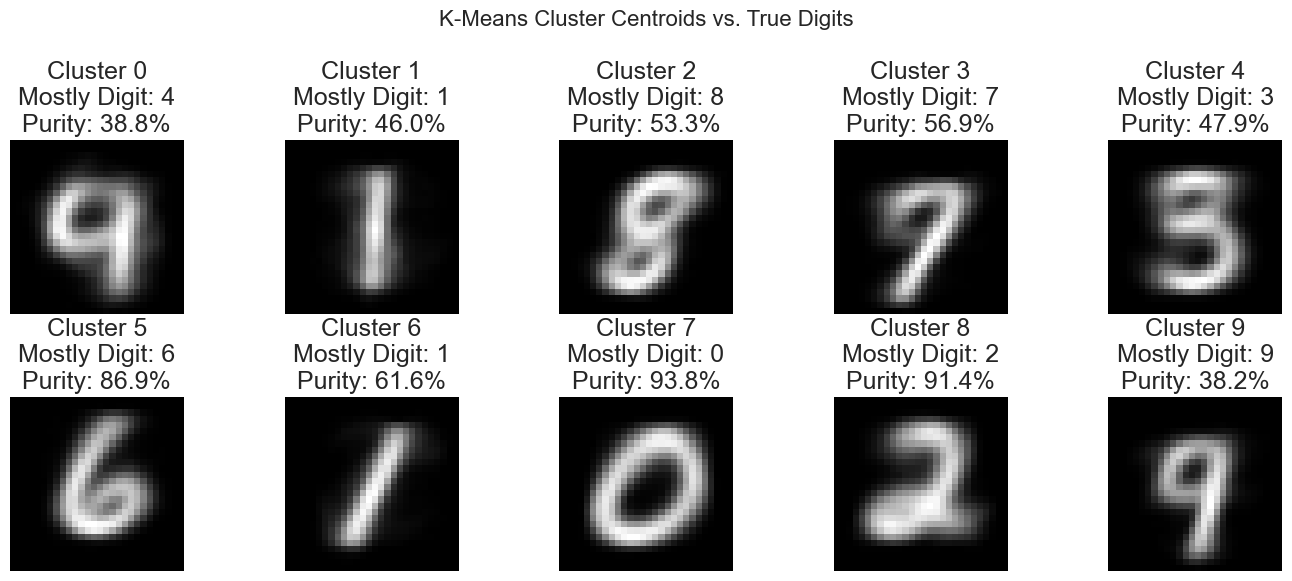

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = axes.flatten()

for i in range(10):
    # Get all images assigned to cluster i
    cluster_mask = cluster_labels == i
    cluster_images = X[cluster_mask]

    if len(cluster_images) > 0:
        # Calculate the average image (centroid)
        avg_img = cluster_images.mean(axis=0).reshape(28, 28)

        # Find the most common TRUE digit in this cluster
        true_digits_in_cluster = y[cluster_mask]
        most_common_digit = np.bincount(true_digits_in_cluster).argmax()
        purity = (
            np.bincount(true_digits_in_cluster)[most_common_digit]
            / len(true_digits_in_cluster)
            * 100
        )

        axes[i].imshow(avg_img, cmap="gray")
        axes[i].set_title(
            f"Cluster {i}\nMostly Digit: {most_common_digit}\nPurity: {purity:.1f}%"
        )
        axes[i].axis("off")

plt.suptitle("K-Means Cluster Centroids vs. True Digits", fontsize=16)
plt.tight_layout()
plt.show()